<a href="https://www.kaggle.com/code/mahabub001cs/batch-vs-stochastic-vs-mini-batch-gradient-descent?scriptVersionId=346459600" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nani123456789/social-network-ads/Social_Network_Ads.csv


In [2]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nani123456789/social-network-ads/Social_Network_Ads.csv')

In [4]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [5]:
df = df[['Age','EstimatedSalary','Purchased']]

In [6]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

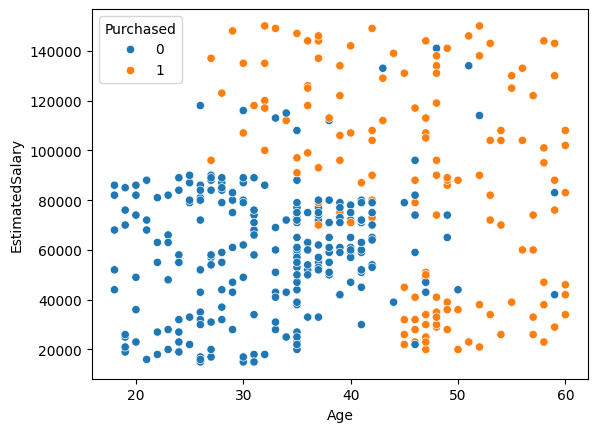

In [7]:
sns.scatterplot(data = df, x = 'Age', y = 'EstimatedSalary', hue = 'Purchased')

In [8]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
X_scaled.shape

(400, 2)

# Difference between Batch, Stochastic and Mini-batch Gradient Descent

| Feature | Batch Gradient Descent | Stochastic Gradient Descent | Mini-Batch Gradient Descent |
|---|---|---|---|
| Data used per update | Entire dataset | One sample | Small batch of samples |
| Batch size | `n` | `1` | `b` (e.g. 32, 64) |
| Updates per epoch | 1 | `n` | `n / b` |
| Speed per update | Slow | Fast | Fast |
| Convergence | Stable | Noisy | More stable |
| Memory usage | High | Low | Medium |
| Computational efficiency | Lower for large data | Good | Usually best |
| Common use | Small datasets | Online learning | Deep learning |

# 1. Batch Gradient Descent

In [11]:
model_batch = Sequential()

model_batch.add(Dense(10, activation = 'relu', input_dim = 2))
model_batch.add(Dense(10, activation = 'relu'))
model_batch.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-01 08:36:08.085042: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
model_batch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model_batch.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])

history = model_batch.fit(X_scaled, y, epochs = 500, batch_size = len(X_scaled), validation_split = 0.2)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2875 - loss: 0.7074 - val_accuracy: 0.6375 - val_loss: 0.4884
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.2875 - loss: 0.7005 - val_accuracy: 0.6375 - val_loss: 0.4901
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.2937 - loss: 0.6958 - val_accuracy: 0.6375 - val_loss: 0.4914
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.3156 - loss: 0.6919 - val_accuracy: 0.6500 - val_loss: 0.4925
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.3281 - loss: 0.6886 - val_accuracy: 0.6625 - val_loss: 0.4934
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3375 - loss: 0.6856 - val_accuracy: 0.6875 - val_loss: 0.4942
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3406 - loss: 0.6829 - val_accuracy: 0.7000 - val_loss: 0.4951
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3562 - loss: 0.6803 - val_accuracy: 0.7000 - val_los

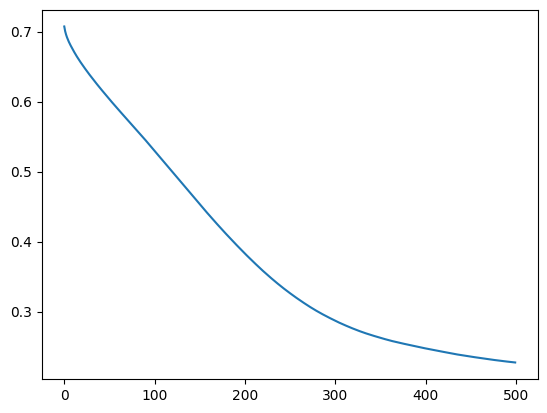

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()

# 2. Stochastic Gradient Descent

In [15]:
model_stochastic = Sequential()

model_stochastic.add(Dense(10, activation = 'relu', input_dim = 2))
model_stochastic.add(Dense(10, activation = 'relu'))
model_stochastic.add(Dense(1, activation = 'sigmoid'))


In [16]:
model_stochastic.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_stochastic.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])

start = time.time()
history = model_stochastic.fit(X_scaled, y, batch_size = 1, epochs = 500, validation_split = 0.2)
print(time.time() - start)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7625 - loss: 0.5691 - val_accuracy: 0.5375 - val_loss: 0.6851
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8344 - loss: 0.3926 - val_accuracy: 0.7000 - val_loss: 0.5877
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8687 - loss: 0.3198 - val_accuracy: 0.7750 - val_loss: 0.4947
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8625 - loss: 0.2917 - val_accuracy: 0.7875 - val_loss: 0.4265
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8625 - loss: 0.2870 - val_accuracy: 0.8500 - val_loss: 0.3782
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8687 - loss: 0.2860 - val_accuracy: 0.9000 - val_loss: 0.3391
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8687 - loss: 0.2784 - val_accuracy: 0.9250 - val_loss: 0.2982
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8719 - loss: 0.2737 - val_accu

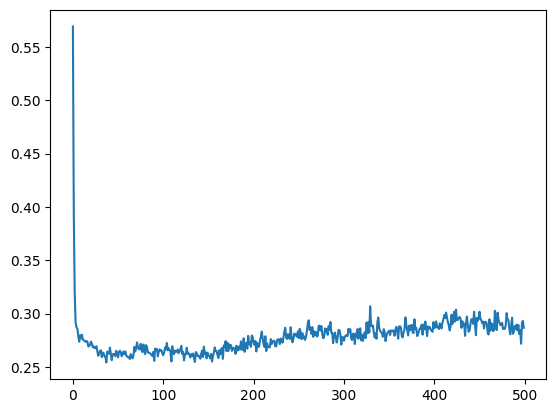

In [18]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()

# 3. Mini-Batch Gradient Descent

In [19]:
model_mini_batch = Sequential()

model_mini_batch.add(Dense(10, activation = 'relu', input_dim = 2))
model_mini_batch.add(Dense(10, activation = 'relu'))
model_mini_batch.add(Dense(1, activation = 'sigmoid'))

In [20]:
model_mini_batch.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])

start = time.time()
history = model_mini_batch.fit(X_scaled, y, batch_size = 32, epochs = 500, validation_split = 0.2)
print(time.time() - start)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6750 - loss: 0.6408 - val_accuracy: 0.4000 - val_loss: 0.7369
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7437 - loss: 0.6147 - val_accuracy: 0.4125 - val_loss: 0.7308
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7656 - loss: 0.5950 - val_accuracy: 0.4125 - val_loss: 0.7253
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7781 - loss: 0.5764 - val_accuracy: 0.4125 - val_loss: 0.7167
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7688 - loss: 0.5587 - val_accuracy: 0.4625 - val_loss: 0.7074
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7750 - loss: 0.5408 - val_accuracy: 0.4875 - val_loss: 0.6974
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7781 - loss: 0.5237 - val_accuracy: 0.5500 - val_loss: 0.6854
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8094 - loss: 0.5065 - val_accuracy: 0.58

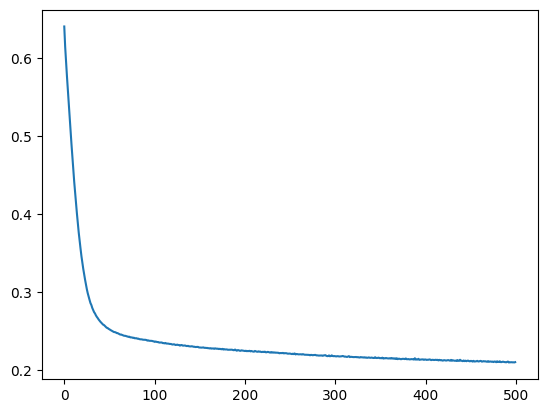

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()